# Resiliency Calibration

Joint indirect-inference calibration of all four placement-mechanism parameters
$(\kappa, \varphi, \tau, \tau_f)$ by matching the simulated normalized signature
curve $\mathrm{VR}(\tau)=C(\tau)/C(1\,\mathrm{s})$ to the empirical 50-day KGHM panel.

**Stage 1** — Empirical micro-MLE (cached, ~17 min first run): profile likelihood
on 2.5 M KGHM limit orders for timescale estimation and significance test.

**Stage 2** — Sim-outcome calibration: iterative quasi-Newton probing all 4
parameters jointly, auto-iterating until $\max|\mathrm{dev}/\mathrm{SE}|<\theta$
at the critical dip horizons (3–10 s).

In [ ]:
import json

import numpy as np
import matplotlib.pyplot as plt

from research_core.classes.helpers import data_dir
from research_core.classes.mo_reversion_calibrate import build_template
from research_core.classes.empirical_placement_mle import run_placement_mle
from research_core.classes.signature_calibration import (
    load_empirical_vr, run_batch_4d, vr_stats, solve_dose_response_nd,
)

t_events = 1_000_000
r_probe  = 10
r_val    = 10
workers  = 10
max_iter = 5
conv_threshold = 2.5

base_overrides = {
    "lo_p_best": 0.10,
    "lo_inside_c1": 0.022021, "lo_inside_c0": 0.006944,
    "lo_inside_c1_hi": 0.003620, "lo_inside_c0_hi": 0.163207,
    "lo_inside_break": 9,
}

target_taus    = np.array([3, 5, 7, 10, 20, 30, 50, 75, 100, 150, 300], float)
target_weights = np.array([4, 4, 4, 2,  2,  2,  2,  2,   2,   2,   2], float)
taus_sim = np.arange(1, 301, dtype=float)

probe_steps = np.array([0.07, 0.08, 2.0, 15.0])
param_lo    = np.array([0.01, 0.0,  1.0, 15.0])
param_hi    = np.array([1.0,  1.0, 30.0, 120.0])

taus_emp, emp_vr, emp_se = load_empirical_vr()
emp_on_grid = np.interp(taus_sim, taus_emp, emp_vr)
template = build_template(T_warmup=100_000, verbose=False)


[build_template] seeded=real-book  T_warmup=100,000  orders=868  mid=[98.12, 98.12] PLN


In [2]:
mle = run_placement_mle()
print(f"Empirical MLE (cached): tau={mle['tau']:.1f}s  tau_flow={mle['tau_flow']:.1f}s  "
      f"kappa={mle['kappa']:.4f}  phi={mle['phi']:.4f}")
if mle['lr_pvalue'] < 0.01:
    lr_label = "significant"
else:
    lr_label = "not significant"
print(f"LR test: stat={mle['lr_stat']:.1f}  p={mle['lr_pvalue']:.2e}  ({lr_label})")
print(f"  {int(mle['n_events']):,} LO events across {int(mle['n_days'])} days")


Loading 50 days from KGHM_order_flow.sqlite ...
  50 days, 2,552,736 LO events
Profile-likelihood grid: 80 points, 12 workers ...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed: 11.9min
[Parallel(n_jobs=12)]: Done  74 out of  80 | elapsed: 17.9min remaining:  1.4min
[Parallel(n_jobs=12)]: Done  80 out of  80 | elapsed: 18.1min finished


Cached MLE result to _cache_empirical_placement_mle.npz
Empirical MLE (cached): tau=4.0s  tau_flow=40.0s  kappa=-0.0477  phi=0.0305
LR test: stat=1770.5  p=0.00e+00  (significant)
  2,552,736 LO events across 50 days


In [6]:
# MLE timescales as starting point; positive amplitudes (sim requires kappa > 0)
center = np.array([0.10, 0.10, mle["tau"], mle["tau_flow"]])

for iteration in range(1, max_iter + 1):
    configs = [tuple(center)]
    for dim_idx in range(4):
        probed = center.copy()
        probed[dim_idx] += probe_steps[dim_idx]
        probed = np.clip(probed, param_lo, param_hi)
        configs.append(tuple(probed))

    print(f"\n--- Iteration {iteration}: "
          f"kappa={center[0]:.4f} phi={center[1]:.4f} "
          f"tau={center[2]:.1f} flow_tau={center[3]:.1f} ---")
    batch = run_batch_4d(template, configs, runs=r_probe, workers=workers,
                         T=t_events, base_overrides=base_overrides)

    vr_c, se_c = vr_stats(batch[configs[0]])

    max_dev = 0.0
    for horizon in target_taus:
        ie = int(np.argmin(np.abs(taus_emp - horizon)))
        i_s = int(np.argmin(np.abs(taus_sim - horizon)))
        dev = abs((vr_c[i_s] - emp_vr[ie]) / max(se_c[i_s], 1e-6))
        if dev > max_dev:
            max_dev = dev
    print(f"  max |dev/SE| across target horizons: {max_dev:.1f}")
    if max_dev < conv_threshold:
        print("  CONVERGED")
        break

    grads = []
    for dim_idx in range(4):
        actual_step = configs[dim_idx + 1][dim_idx] - configs[0][dim_idx]
        if abs(actual_step) < 1e-10:
            grads.append(np.zeros_like(vr_c))
        else:
            grads.append((vr_stats(batch[configs[dim_idx + 1]])[0] - vr_c) / actual_step)

    deltas = solve_dose_response_nd(taus_sim, vr_c, grads, emp_on_grid,
                                    target_taus, target_weights)
    new = center + np.array(deltas)
    new = np.clip(new, param_lo, param_hi)
    if new[3] <= 2 * new[2] + 5:
        new[3] = 2 * new[2] + 5
    print(f"  step: kappa {deltas[0]:+.4f}  phi {deltas[1]:+.4f}  "
          f"tau {deltas[2]:+.1f}  flow_tau {deltas[3]:+.1f}")
    center = new
else:
    print(f"\n  Did not converge in {max_iter} iterations")

kappa_star, phi_star, tau_star, flow_tau_star = center
print(f"\nSolution: kappa={kappa_star:.4f}  phi={phi_star:.4f}  "
      f"tau={tau_star:.1f}  flow_tau={flow_tau_star:.1f}")



--- Iteration 1: kappa=0.1000 phi=0.1000 tau=4.0 flow_tau=40.0 ---
  [1/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (183s)
  [2/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (185s)
  [3/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (186s)
  [4/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (186s)
  [5/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (186s)
  [6/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (187s)
  [7/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (187s)
  [8/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (188s)
  [9/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (189s)
  [10/50] κ=0.100 φ=0.100 τ=4 τf=40 +9 sess (190s)
  [11/50] κ=0.170 φ=0.100 τ=4 τf=40 +9 sess (354s)
  [12/50] κ=0.170 φ=0.100 τ=4 τf=40 +10 sess (361s)
  [13/50] κ=0.170 φ=0.100 τ=4 τf=40 +9 sess (363s)
  [14/50] κ=0.170 φ=0.100 τ=4 τf=40 +9 sess (364s)
  [15/50] κ=0.170 φ=0.100 τ=4 τf=40 +9 sess (364s)
  [16/50] κ=0.170 φ=0.100 τ=4 τf=40 +9 sess (365s)
  [17/50] κ=0.170 φ=0.100 τ=4 τf=40 +10 sess (366s)
  [18/50] κ=0.170 φ=0.100 τ=4 τf=40 +9 sess (366s)
  [19/50] κ=0.170 φ=0

  [1/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (153s)
  [2/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (154s)
  [3/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +10 sess (155s)
  [4/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (155s)
  [5/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (155s)
  [6/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (155s)
  [7/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (156s)
  [8/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (157s)
  [9/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (158s)
  [10/10] κ=0.082 φ=0.075 τ=4.53795 τf=32.3332 +9 sess (158s)


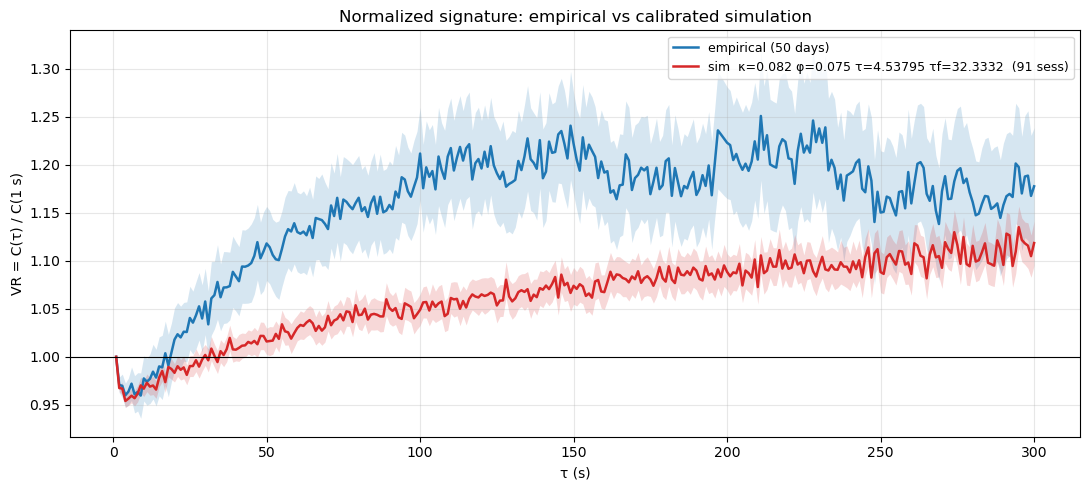

  tau   emp_VR   sim_VR   sim_SE  dev/SE
    3   0.9697   0.9669   0.0060    -0.5
    5   0.9638   0.9564   0.0072    -1.0
    7   0.9609   0.9568   0.0079    -0.5
   10   0.9774   0.9668   0.0081    -1.3
   20   1.0179   0.9833   0.0095    -3.6
   30   1.0576   1.0019   0.0109    -5.1
   50   1.1181   1.0160   0.0138    -7.4
   75   1.1638   1.0380   0.0148    -8.5
  100   1.2117   1.0490   0.0164    -9.9
  150   1.2219   1.0740   0.0191    -7.7
  200   1.2230   1.0885   0.0189    -7.1
  300   1.1776   1.1185   0.0230    -2.6

dip min (2-15 s): emp 0.9596, sim 0.9540


In [7]:
val = run_batch_4d(template, [tuple(center)], runs=r_val, workers=workers,
                   T=t_events, base_overrides=base_overrides)
vr_val, se_val = vr_stats(val[tuple(center)])
n_sess = len(val[tuple(center)])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(taus_emp, emp_vr, lw=1.8, color="tab:blue", label="empirical (50 days)")
ax.fill_between(taus_emp, emp_vr - emp_se, emp_vr + emp_se, color="tab:blue", alpha=0.18, lw=0)
ax.plot(taus_sim, vr_val, lw=1.8, color="tab:red",
        label=(f"sim  κ={kappa_star:.3f} φ={phi_star:.3f} "
               f"τ={tau_star:g} τf={flow_tau_star:g}  ({n_sess} sess)"))
ax.fill_between(taus_sim, vr_val - se_val, vr_val + se_val, color="tab:red", alpha=0.18, lw=0)
ax.axhline(1.0, color="black", lw=0.8)
ax.set_xlabel("τ (s)")
ax.set_ylabel("VR = C(τ) / C(1 s)")
ax.set_title("Normalized signature: empirical vs calibrated simulation")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"{'tau':>5} {'emp_VR':>8} {'sim_VR':>8} {'sim_SE':>8} {'dev/SE':>7}")
for kt in (3, 5, 7, 10, 20, 30, 50, 75, 100, 150, 200, 300):
    ie = int(np.argmin(np.abs(taus_emp - kt)))
    i_s = int(np.argmin(np.abs(taus_sim - kt)))
    dev = (vr_val[i_s] - emp_vr[ie]) / se_val[i_s]
    print(f"{kt:>5} {emp_vr[ie]:>8.4f} {vr_val[i_s]:>8.4f} "
          f"{se_val[i_s]:>8.4f} {dev:>7.1f}")

dip_emp = emp_vr[(taus_emp >= 2) & (taus_emp <= 15)].min()
dip_sim = vr_val[(taus_sim >= 2) & (taus_sim <= 15)].min()
print(f"\ndip min (2-15 s): emp {dip_emp:.4f}, sim {dip_sim:.4f}")


In [8]:
result = {
    "resil_kappa": round(float(kappa_star), 4),
    "resil_tau_s": round(float(tau_star), 1),
    "resil_phi": round(float(phi_star), 4),
    "resil_flow_tau_s": round(float(flow_tau_star), 1),
    **base_overrides,
    "T_events": t_events,
    "runs_probe": r_probe,
    "runs_validation": r_val,
    "n_validation_sessions": n_sess,
    "dip_min_emp": round(float(dip_emp), 4),
    "dip_min_sim": round(float(dip_sim), 4),
    "mle_tau": mle["tau"],
    "mle_tau_flow": mle["tau_flow"],
    "mle_kappa": round(float(mle["kappa"]), 4),
    "mle_phi": round(float(mle["phi"]), 4),
    "mle_lr_stat": round(float(mle["lr_stat"]), 1),
}
out_path = data_dir() / "resiliency_calibration.json"
with open(out_path, "w") as f:
    json.dump(result, f, indent=2)

np.savez_compressed(
    data_dir() / "resiliency_calibration_curves.npz",
    taus=taus_sim, validation_curves=val[tuple(center)],
    kappa=kappa_star, phi=phi_star, tau_s=tau_star, flow_tau_s=flow_tau_star,
)
print(json.dumps(result, indent=2))


{
  "resil_kappa": 0.0817,
  "resil_tau_s": 4.5,
  "resil_phi": 0.0746,
  "resil_flow_tau_s": 32.3,
  "lo_p_best": 0.1,
  "lo_inside_c1": 0.022021,
  "lo_inside_c0": 0.006944,
  "lo_inside_c1_hi": 0.00362,
  "lo_inside_c0_hi": 0.163207,
  "lo_inside_break": 9,
  "T_events": 1000000,
  "runs_probe": 10,
  "runs_validation": 10,
  "n_validation_sessions": 91,
  "dip_min_emp": 0.9596,
  "dip_min_sim": 0.954,
  "mle_tau": 4.0,
  "mle_tau_flow": 40.0,
  "mle_kappa": -0.0477,
  "mle_phi": 0.0305,
  "mle_lr_stat": 1770.5
}
